Loaded: /Users/sterinsaji/Desktop/rag-research/notebooks/final_all_dataset/150_filtered/combined_scores_final.csv
Hybrid Detector
Accuracy : 0.700
Precision: 0.765
Recall   : 0.722
F1 Score : 0.743

              precision    recall  f1-score   support

           0       0.62      0.67      0.64        12
           1       0.76      0.72      0.74        18

    accuracy                           0.70        30
   macro avg       0.69      0.69      0.69        30
weighted avg       0.70      0.70      0.70        30



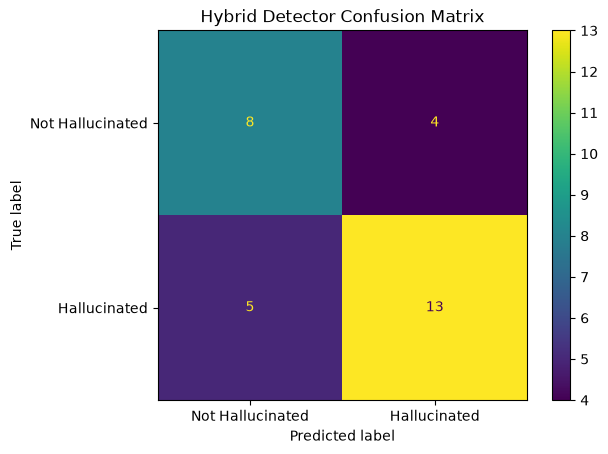


Feature Importance
----------------------
     Detector    Weight
1       ragas  2.176395
3  similarity  1.236368
2   selfcheck -0.059740
0    baseline -0.236692

Saved as /Users/sterinsaji/Desktop/rag-research/notebooks/final_all_dataset/hybrid_predictions.csv


In [2]:
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

#######################################################
# Load dataset
#######################################################

# Try a few common locations so the notebook works from different cwd values.
candidate_paths = [
    Path("combined_scores_final.csv"),
    Path("150_filtered/combined_scores_final.csv"),
    Path("final_all_dataset/150_filtered/combined_scores_final.csv"),
    Path("notebooks/final_all_dataset/150_filtered/combined_scores_final.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    searched = "\n".join(str(p.resolve()) for p in candidate_paths)
    raise FileNotFoundError(
        "combined_scores_final.csv not found. Checked:\n" + searched
    )

df = pd.read_csv(data_path)
print(f"Loaded: {data_path.resolve()}")

# Remove missing rows
df = df.dropna()

#######################################################
# Features
#######################################################

X = df[[
    "baseline",
    "ragas",
    "selfcheck",
    "similarity"
]]

y = df["human"]

#######################################################
# Train/Test Split
#######################################################

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#######################################################
# Train Logistic Regression
#######################################################

model = LogisticRegression()

model.fit(X_train, y_train)

#######################################################
# Predict
#######################################################

y_pred = model.predict(X_test)

#######################################################
# Metrics
#######################################################

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("==============")
print("Hybrid Detector")
print("==============")

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

print()

print(classification_report(y_test, y_pred))

#######################################################
# Confusion Matrix
#######################################################

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Hallucinated","Hallucinated"]
)

disp.plot()

plt.title("Hybrid Detector Confusion Matrix")

plt.show()

#######################################################
# Feature Importance
#######################################################

importance = pd.DataFrame({
    "Detector": X.columns,
    "Weight": model.coef_[0]
})

importance = importance.sort_values(
    by="Weight",
    ascending=False
)

print("\nFeature Importance")
print("----------------------")
print(importance)

#######################################################
# Predict Every Sample
#######################################################

df["hybrid_prediction"] = model.predict(X)

#######################################################
# Save
#######################################################

output_path = Path("hybrid_predictions.csv")
df.to_csv(output_path, index=False)

print(f"\nSaved as {output_path.resolve()}")

In [3]:
# save the model for future use
save_model_path = Path("hybrid_detector_model.pkl")
import joblib
joblib.dump(model, save_model_path)
print(f"Saved model as {save_model_path.resolve()}")

Saved model as /Users/sterinsaji/Desktop/rag-research/notebooks/final_all_dataset/hybrid_detector_model.pkl


In [4]:
# create a summary of the results
summary = pd.DataFrame({
    "Detector": ["baseline", "ragas", "selfcheck", "similarity", "hybrid"],
    "Accuracy": [
        accuracy_score(y_test, X_test["baseline"]),
        accuracy_score(y_test, X_test["ragas"]),
        accuracy_score(y_test, X_test["selfcheck"]),
        accuracy_score(y_test, X_test["similarity"]),
        accuracy_score(y_test, y_pred)
    ],
    "Precision": [
        precision_score(y_test, X_test["baseline"]),
        precision_score(y_test, X_test["ragas"]),
        precision_score(y_test, X_test["selfcheck"]),
        precision_score(y_test, X_test["similarity"]),
        precision_score(y_test, y_pred)
    ],
    "Recall": [
        recall_score(y_test, X_test["baseline"]),
        recall_score(y_test, X_test["ragas"]),
        recall_score(y_test, X_test["selfcheck"]),
        recall_score(y_test, X_test["similarity"]),
        recall_score(y_test, y_pred)
    ],
    "F1": [
        f1_score(y_test, X_test["baseline"]),
        f1_score(y_test, X_test["ragas"]),
        f1_score(y_test, X_test["selfcheck"]),
        f1_score(y_test, X_test["similarity"]),
        f1_score(y_test, y_pred)
    ]
})  


In [6]:
summary

,Detector,Accuracy,Precision,Recall,F1
0,baseline,0.433333,0.600000,0.166667,0.260870
1,ragas,0.666667,0.722222,0.722222,0.722222
2,selfcheck,0.600000,0.600000,1.000000,0.750000
3,similarity,0.700000,0.764706,0.722222,0.742857
4,hybrid,0.700000,0.764706,0.722222,0.742857


In [9]:
print(model)
print(model.n_features_in_)
if hasattr(model, "feature_names_in_"):
    print(model.feature_names_in_)
else:
    print("Feature names not stored.")

LogisticRegression()
4
['baseline' 'ragas' 'selfcheck' 'similarity']
